# Evaluation of Gliner2 performances

## Definitions

- true positives (TP) = number of entities of the ground truth found by the model
- false positives (FP) = number of entities not in the ground truth found by the model
- false negatives (FN) = number of entities of the ground truth not found by the model

$$
{\rm precision} = \frac{TP}{TP + FP}
$$

$$
{\rm recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \frac{ {\rm precision} \times {\rm recall} }{ {\rm precision}+{\rm recall} } = \frac{ 2 TP }{ 2TP + FP + FN }
$$


$$
F_{\beta} = \frac{ (1 + \beta^2) \times {\rm precision} \times {\rm recall} }{ (\beta^2 \times {\rm precision}) + {\rm recall} } = \frac{ (1 + \beta^2) \times TP }{ \beta^2 \times (TP + FN) + TP + FP }
$$

In the case of Named Entity Recognition, we focus more on precision than recall. We want the model to make no mistakes rather that identify all entities.

In [176]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy  as np
import pandas as pd
pd.__version__

'2.2.3'

In [185]:
def compute_score_by_label(results_file_path: Path, model_name: str) -> pd.DataFrame:
    raw_df = pd.read_parquet(results_file_path)
    # Aggregate columns.
    agg_df = (raw_df
     .query("model_name == @model_name")
     .groupby("label")
     .agg(
        model_name=("model_name", "first"),
        nb_of_texts_with_label=("json_path", "nunique"),
        total_is_format_valid=("is_format_valid", "sum"),
        total_has_no_hallucination=("has_no_hallucination", "sum"),
        true_positives=("true_positives", "sum"),
        false_positives=("false_positives", "sum"),
        false_negatives=("false_negatives", "sum"),
     )
    )
    # Add missing columns.
    agg_df.loc["overall"] = agg_df.sum(numeric_only=True)
    agg_df.loc["overall", "model_name"] = agg_df.iloc[0]["model_name"]
    agg_df["pct_is_format_valid"] = agg_df["total_is_format_valid"] / agg_df["nb_of_texts_with_label"] * 100
    agg_df["pct_has_no_hallucination"] = agg_df["total_has_no_hallucination"] / agg_df["nb_of_texts_with_label"] * 100
    agg_df["precision"] = agg_df["true_positives"] / ( agg_df["true_positives"] + agg_df["false_positives"] )
    agg_df["recall"] = agg_df["true_positives"] / ( agg_df["true_positives"] + agg_df["false_negatives"] )
    agg_df["F1"] = 2 * ( agg_df["precision"] * agg_df["recall"] ) / ( agg_df["precision"] + agg_df["recall"] )
    beta = 0.5
    agg_df["Fbeta0.5"] = ( (1 + beta**2) * agg_df["precision"] * agg_df["recall"] ) / ( beta**2 * agg_df["precision"] + agg_df["recall"] )
    # Update type for columns.
    col_name_to_int = [
        "nb_of_texts_with_label", "pct_is_format_valid", "pct_has_no_hallucination",
        "true_positives", "false_positives", "false_negatives"
    ]
    for col_name in col_name_to_int:
        agg_df[col_name] = agg_df[col_name].astype("int")
    # Reorder index.
    new_index = ["MOL", "FFM", "SOFTNAME", "SOFTVERS", "STIME", "TEMP", "overall"]
    agg_df = agg_df.reindex(new_index)
    # Add label as columns.
    agg_df["label"] = agg_df.index
    # Reorder columns and remove unused columns.
    agg_df = agg_df[[
        "model_name", "label",
        "nb_of_texts_with_label", "pct_is_format_valid", "pct_has_no_hallucination",
        "true_positives", "false_positives", "false_negatives",
        "precision", "recall", "F1", "Fbeta0.5"
    ]]
    return agg_df

In [186]:
scores_df = compute_score_by_label(
    results_file_path="../../results/per_text_class_metrics_GLiNER2_Base_205M_parameters_20260331.parquet",
    model_name="GLiNER2 Small (205M parameters) finetuned"
)

scores_df.style.format(precision=2)

,model_name,label,nb_of_texts_with_label,pct_is_format_valid,pct_has_no_hallucination,true_positives,false_positives,false_negatives,precision,recall,F1,Fbeta0.5
label,,,,,,,,,,,,
MOL,GLiNER2 Small (205M parameters) finetuned,MOL,20,100,100,44,21,58,0.68,0.43,0.53,0.61
FFM,GLiNER2 Small (205M parameters) finetuned,FFM,20,100,100,23,9,24,0.72,0.49,0.58,0.66
SOFTNAME,GLiNER2 Small (205M parameters) finetuned,SOFTNAME,17,100,100,10,17,14,0.37,0.42,0.39,0.38
SOFTVERS,GLiNER2 Small (205M parameters) finetuned,SOFTVERS,11,100,100,3,10,10,0.23,0.23,0.23,0.23
STIME,GLiNER2 Small (205M parameters) finetuned,STIME,16,100,100,20,7,2,0.74,0.91,0.82,0.77
TEMP,GLiNER2 Small (205M parameters) finetuned,TEMP,12,100,100,14,1,2,0.93,0.88,0.90,0.92
overall,GLiNER2 Small (205M parameters) finetuned,overall,96,100,100,114,65,110,0.64,0.51,0.57,0.61


In [187]:
df1 = compute_score_by_label(
    results_file_path="../../results/per_text_class_metrics_GLiNER2_Base_205M_parameters_20260331.parquet",
    model_name="GLiNER2 Small (205M parameters) finetuned"
)
df1["model_name"] = "gliner2-base-small"
df2 = compute_score_by_label(
    results_file_path="../../results/per_text_class_metrics_GLiNER2_Large_340M_parameters_20260331.parquet",
    model_name="GLiNER2 Small (205M parameters) finetuned"
)
df2["model_name"] = "gliner2-base-large"
all_df = pd.concat([df1, df2], ignore_index=True)
all_df

,model_name,label,nb_of_texts_with_label,pct_is_format_valid,pct_has_no_hallucination,true_positives,false_positives,false_negatives,precision,recall,F1,Fbeta0.5
0,gliner2-base-small,MOL,20,100,100,44,21,58,0.676923,0.431373,0.526946,0.607735
1,gliner2-base-small,FFM,20,100,100,23,9,24,0.718750,0.489362,0.582278,0.657143
2,gliner2-base-small,SOFTNAME,17,100,100,10,17,14,0.370370,0.416667,0.392157,0.378788
3,gliner2-base-small,SOFTVERS,11,100,100,3,10,10,0.230769,0.230769,0.230769,0.230769
4,gliner2-base-small,STIME,16,100,100,20,7,2,0.740741,0.909091,0.816327,0.769231
5,gliner2-base-small,TEMP,12,100,100,14,1,2,0.933333,0.875000,0.903226,0.921053
6,gliner2-base-small,overall,96,100,100,114,65,110,0.636872,0.508929,0.565757,0.606383
7,gliner2-base-large,MOL,20,100,100,49,40,53,0.550562,0.480392,0.513089,0.534934
8,gliner2-base-large,FFM,20,100,100,21,13,26,0.617647,0.446809,0.518519,0.573770
9,gliner2-base-large,SOFTNAME,17,100,100,17,4,7,0.809524,0.708333,0.755556,0.787037


In [203]:
def make_plot_compare_scores_models(df):
    scores = ["precision", "recall", "F1", "Fbeta0.5"]
    colors = ["#bae1ff", "#cdb4db", "#ffffba", "#ffffe4", "#baffc9", "#ffb3ba", "silver"]
    model_names = df["model_name"].unique()
    labels = df["label"].unique()
    labels_index = np.arange(len(labels))
    plt.rcParams.update({"font.size": 14})
    for score in scores:
        fig, ax = plt.subplots(figsize=(12, 6))
        bar_width = (1.0 - 0.2)/len(model_names)
        for model_index, model_name in enumerate(model_names):
            shift = bar_width * (len(model_names) - 1) / 2
            positions = labels_index - shift + model_index * width
            values = np.array(df[df["model_name"] == model_name][score])
            ax.bar(positions, values, width=width, edgecolor="grey", color=colors)
            for x, y in zip(positions, values):
                ax.text(x, y + 0.02, model_name, horizontalalignment="center", rotation=90, color="dimgrey")
                ax.text(x, y - 0.04, f"{y:.2f}", horizontalalignment="center", size=10, color="dimgrey")
        ax.set_xticks(labels_index, labels, weight="bold", rotation=45, ha="center")
        ax.set(ylim=(0,1))
        ax.set_ylabel(score, weight="bold")
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="lightgrey")
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

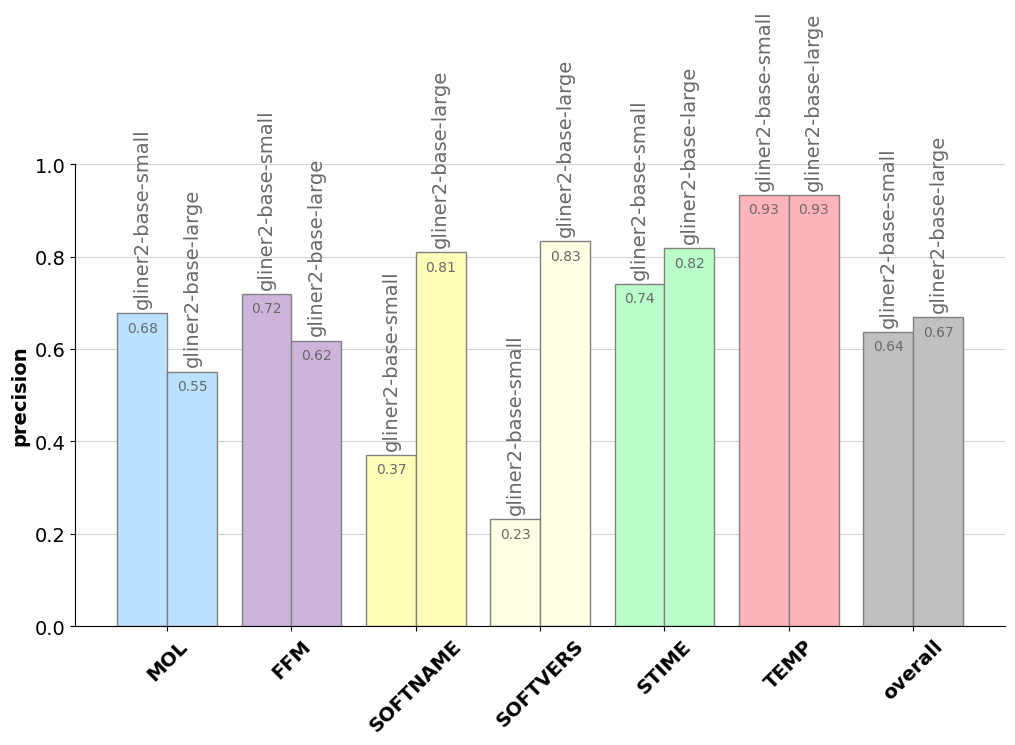

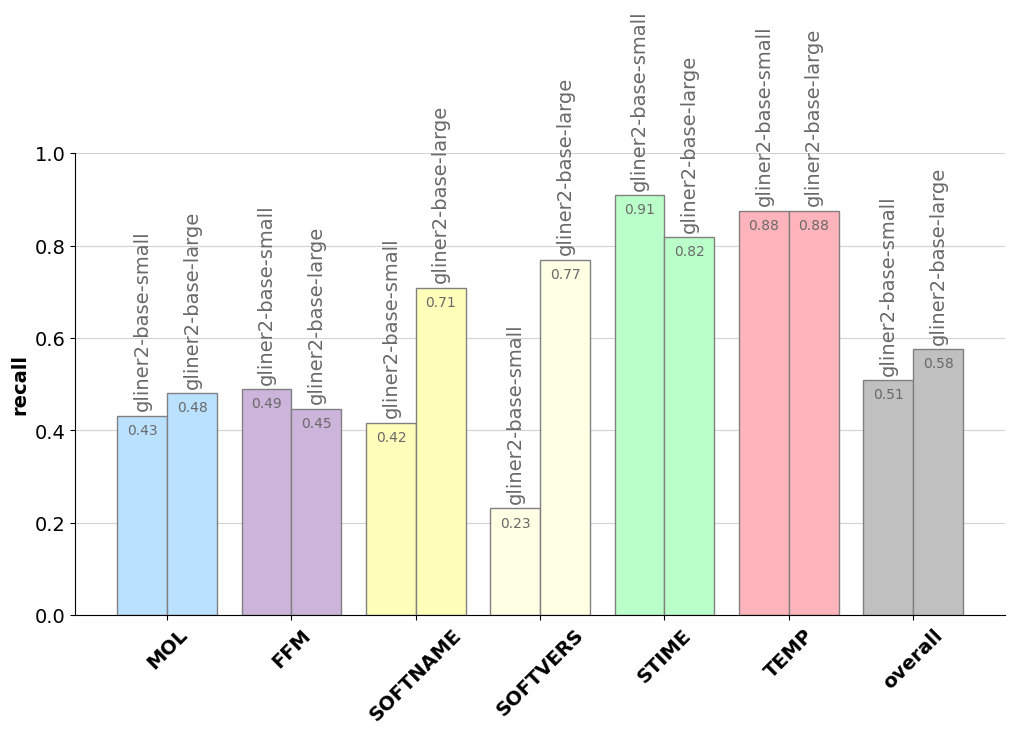

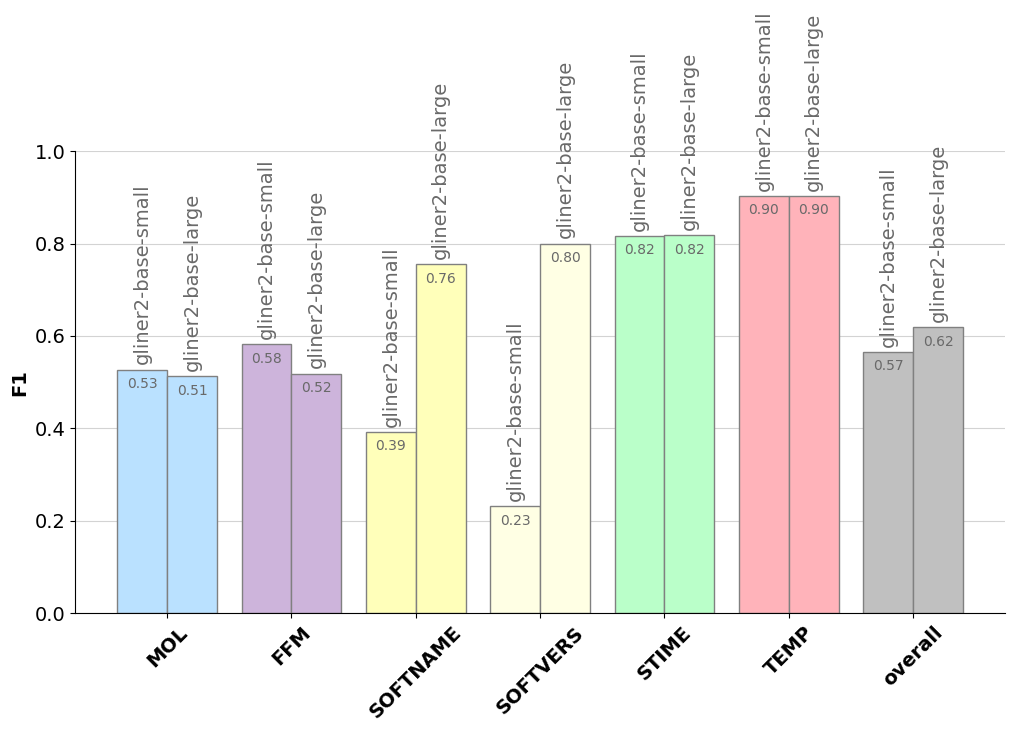

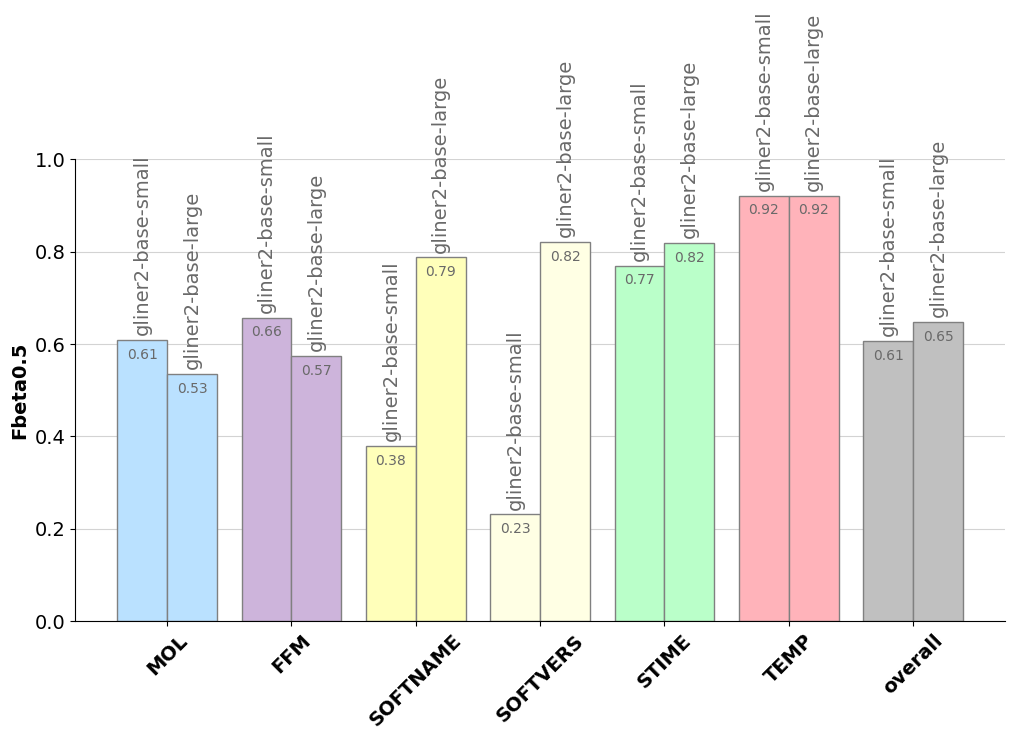

In [204]:
make_plot_compare_scores_models(all_df)